In [2]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [3]:
import pickle
from pathlib import Path

import numpy as np
import numpy.random as npr
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
from scipy.optimize import linear_sum_assignment
import statsmodels.formula.api as smf

from imports import *
from config import dir_config
from src.utils import pmf_utils
from src.shared_glm_hmm.grouping import session_metadata

In [4]:
processed_dir = Path(dir_config.data.processed)
shared_dir = processed_dir / "shared_glm_hmm"

metadata = pd.read_csv(processed_dir / "processed_metadata_all_data_accu_60.csv")
sess_md = session_metadata(metadata).set_index("session_id")

# trial-level behaviour (for per-trial color when a config lacks the color regressor)
behavior_df = pd.read_csv(processed_dir / "processed_all_data_accu_60_all.csv")
behavior_df["outcome"] = behavior_df["outcome"].fillna(-1)


## Select model for the within-subject analysis

The panels above compare all runs. Pick **one** model here; sections 1–6 below run on it.

In [5]:
SELECTED = "XY__tgt"   # the model for the downstream within-subject analysis

CONFIG = SELECTED
bundle = pickle.load(open(shared_dir / CONFIG / "all_subjects_final.pkl", "rb"))
pooled = bundle["model"]["pooled"]
feats  = bundle["config"]["model_features"]
K      = bundle["best_k"]
data   = bundle["data"]


STATE_COLORS = ["#ff7f00", "#4daf4a", "#377eb8", "#e41a1c", "#984ea3", "#a65628", "#999999"]
GROUP_LABELS = {
    ("HC", "none"): "HC",
    ("tremor", "off"): "Tremor OFF",
    ("tremor", "on"): "Tremor ON",
    ("bradykinetic", "off"): "Brady OFF",
    ("bradykinetic", "on"): "Brady ON",
    ("intermediate", "off"): "Interm OFF",
    ("intermediate", "on"): "Interm ON",
}


In [ ]:
def get_state_colors(Kn):
    return [STATE_COLORS[k % len(STATE_COLORS)] for k in range(Kn)]


def state_label(k):
    return f"State {k + 1}"


def _align(w, ref):
    cost = np.array([[np.sum((w[i] - ref[j]) ** 2) for j in range(len(ref))] for i in range(len(w))])
    _, col = linear_sum_assignment(cost)
    inv = np.empty_like(col)
    inv[col] = np.arange(len(col))
    return inv


def get_session_color(sid, n_back):
    """Per-trial color for one session, trimmed to match the bundle (process_sessions logic)."""
    td = behavior_df[behavior_df["session_id"] == sid].reset_index(drop=True)
    valid_idx = np.where(td["outcome"].values != -1)[0]
    first_trial = valid_idx[n_back - 1] + 1
    return td["color"].values[first_trial:]


def build_group_data(bundle, sess_md):
    """{group_tuple: {session_weights, session_occupancy, session_predicted_dfs}} on shared basis."""
    ref_w = -bundle["model"]["pooled"].observations.params[:, 0, :]  # (K, M) this run's shared basis
    n_back = bundle["config"].get("n_trials_back", 1)
    groups = {}
    for sid, m in bundle["model"]["models"].items():
        if sid not in sess_md.index:
            continue
        g = (sess_md.loc[sid, "subtype"], sess_md.loc[sid, "medication"])
        df = bundle["data"][sid]
        X = df[feats].values.astype(float)
        y = df["choices"].values.astype(int).reshape(-1, 1)
        msk = df["mask"].values.astype(bool).reshape(-1, 1)
        post = m.expected_states(data=y, input=X, mask=msk)[0]  # (T, K)
        w = -m.observations.params[:, 0, :]
        perm = _align(w, ref_w)
        valid = msk[:, 0]
        # expected choice prob (permutation-invariant)
        wsum = np.einsum("tm,km->tk", X, w)
        sig = 1 / (1 + np.exp(-wsum))
        ecp = (sig * post).sum(1)
        color_raw = df["color"].values if "color" in df.columns else get_session_color(sid, n_back)
        pdf = pd.DataFrame(
            {
                "stimulus": df["stimulus"].values[valid],
                "choices": y[valid, 0],
                "color": (color_raw[valid] > 0).astype(int),  # equal=0, unequal=1
                "expected_choice_prob": np.clip(ecp[valid], 1e-6, 1 - 1e-6),
            }
        )
        gd = groups.setdefault(g, {"session_weights": {}, "session_occupancy": {}, "session_predicted_dfs": {}})
        gd["session_weights"][sid] = w[perm]
        gd["session_occupancy"][sid] = post[:, perm][valid].mean(0)
        gd["session_predicted_dfs"][sid] = pdf
    return groups


def compute_group_psychometrics(predicted_dfs):
    conditions = [(0, "Equal", "gray"), (1, "Unequal", "black")]
    result = {}
    for cval, label, color in conditions:
        actual, model = [], []
        x_bins = x_hat = None
        for pdf in predicted_dfs.values():
            sub = pdf[pdf["color"] == cval]
            if len(sub) < 5:
                continue
            stim = sub["stimulus"].to_numpy() * 100
            ch = sub["choices"].values.astype(int)
            ep = sub["expected_choice_prob"].values
            try:
                xd, yd, _, xh, _ = pmf_utils.get_psychometric_data({"signed_coherence": stim, "choice": ch})
                actual.append(yd)
                if x_bins is None:
                    x_bins, x_hat = xd, xh
                # _, ym, _, _, _ = pmf_utils.get_psychometric_data({"signed_coherence": stim, "choice": npr.binomial(1, ep)})
                ym = np.array([ep[stim == c].mean() for c in x_bins])
                model.append(ym)
            except Exception:
                continue
        if not actual:
            continue
        ya, ym = np.array(actual), np.array(model)
        S = len(actual)

        def safe_fit(y):
            try:
                return pmf_utils.fit_psychometric_function(x_bins, y, trial_counts=None, model_type="logit_4").predict(x_hat)
            except Exception:
                return None

        result[cval] = dict(
            label=label,
            color=color,
            x_bins=x_bins,
            x_hat=x_hat,
            actual=actual,
            model=model,
            mean_actual=ya.mean(0),
            sem_actual=ya.std(0) / np.sqrt(S),
            mean_model=ym.mean(0),
            sem_model=ym.std(0) / np.sqrt(S),
            fit_actual=safe_fit(ya.mean(0)),
            fit_model=safe_fit(ym.mean(0)),
        )
    return result

def plot_color_psych(ax, gp, mode, title=""):
    for cval in sorted(gp):
        c = gp[cval]
        col = c["color"]
        for ys in c[mode]:
            ax.plot(c["x_bins"], ys, "o-", color=col, alpha=0.08, lw=0.8, ms=3)
        ax.errorbar(c["x_bins"], c[f"mean_{mode}"], yerr=c[f"sem_{mode}"], color=col, marker="o", ms=9, mec="k", ls="", label=c["label"], elinewidth=2, capsize=7)
        if c[f"fit_{mode}"] is not None:
            ax.plot(c["x_hat"], c[f"fit_{mode}"], color=col, ls="-", lw=2.5)
    ax.axhline(0.5, color="k", ls=":", lw=0.8)
    ax.set(xlabel="Coherence (%)", ylabel="P(right)", xlim=(-105, 105), ylim=(-0.05, 1.05), xticks=[-100, -35, -13, 0, 13, 35, 100], title=title)
    ax.legend(fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)


def plot_group_row(axrow, group, gd):
    label = GROUP_LABELS.get(group, str(group))
    colors = get_state_colors(K)
    ax_beh, ax_mdl, ax_psych, ax_w, ax_occ = axrow
    gp = compute_group_psychometrics(gd["session_predicted_dfs"])
    plot_color_psych(ax_beh, gp, "actual", f"{label} — Behavior")
    plot_color_psych(ax_mdl, gp, "model", f"{label} — GLM-HMM")

    Wg = np.stack(list(gd["session_weights"].values()))
    S = len(Wg)
    Og = np.stack(list(gd["session_occupancy"].values()))
    mean_w, sem_w = Wg.mean(0), Wg.std(0) / np.sqrt(S)
    mean_o, sem_o = Og.mean(0), Og.std(0) / np.sqrt(S)

    si = feats.index("stimulus") if "stimulus" in feats else 0
    bi = feats.index("bias") if "bias" in feats else None

    ci = next((i for i, f in enumerate(feats) if f == "color"), None)
    cXs_i = next((i for i, f in enumerate(feats) if "color" in f and "stim" in f.lower()), None)

    xr = np.linspace(-1, 1, 200)

    for k in range(K):
        for c in [0, 1]:
            logit = mean_w[k, si] * xr
            if bi is not None:
                logit += mean_w[k, bi]
            if ci is not None:
                logit += mean_w[k, ci] * c
            if cXs_i is not None:
                logit += mean_w[k, cXs_i] * xr * c
            ls = "--" if c == 0 else "-"
            ax_psych.plot(xr * 100, 1 / (1 + np.exp(-logit)), color=colors[k], lw=2, ls=ls, label=state_label(k))

    ax_psych.axhline(0.5, color="k", ls=":", lw=0.8)
    ax_psych.set(xlabel="Coherence (%)", ylabel="P(right)", ylim=(0, 1), title=f"{label} — states")
    ax_psych.legend(fontsize=7)

    xf = np.arange(len(feats))
    for k in range(K):
        ax_w.errorbar(xf, mean_w[k], yerr=sem_w[k], color=colors[k], marker="o", lw=1.4, capsize=3, label=state_label(k))
    ax_w.axhline(0, color="k", ls="--", lw=0.8)
    ax_w.set_xticks(xf)
    ax_w.set_xticklabels(feats, rotation=20, ha="right", fontsize=8)
    ax_w.set(ylabel="GLM weight", title="Weights (mean ± SEM)")
    ax_w.legend(fontsize=7)

    xk = np.arange(K)
    ax_occ.bar(xk, mean_o, color=colors, alpha=0.85, yerr=sem_o, capsize=4)
    for k in range(K):
        ax_occ.scatter(np.full(S, k) + np.random.uniform(-0.15, 0.15, S), Og[:, k], color=colors[k], s=10, alpha=0.5, zorder=3)
    ax_occ.set_xticks(xk)
    ax_occ.set_xticklabels([f"S{k+1}" for k in range(K)])
    ax_occ.set(ylabel="Occupancy", ylim=(0, 1), title="State occupancy")

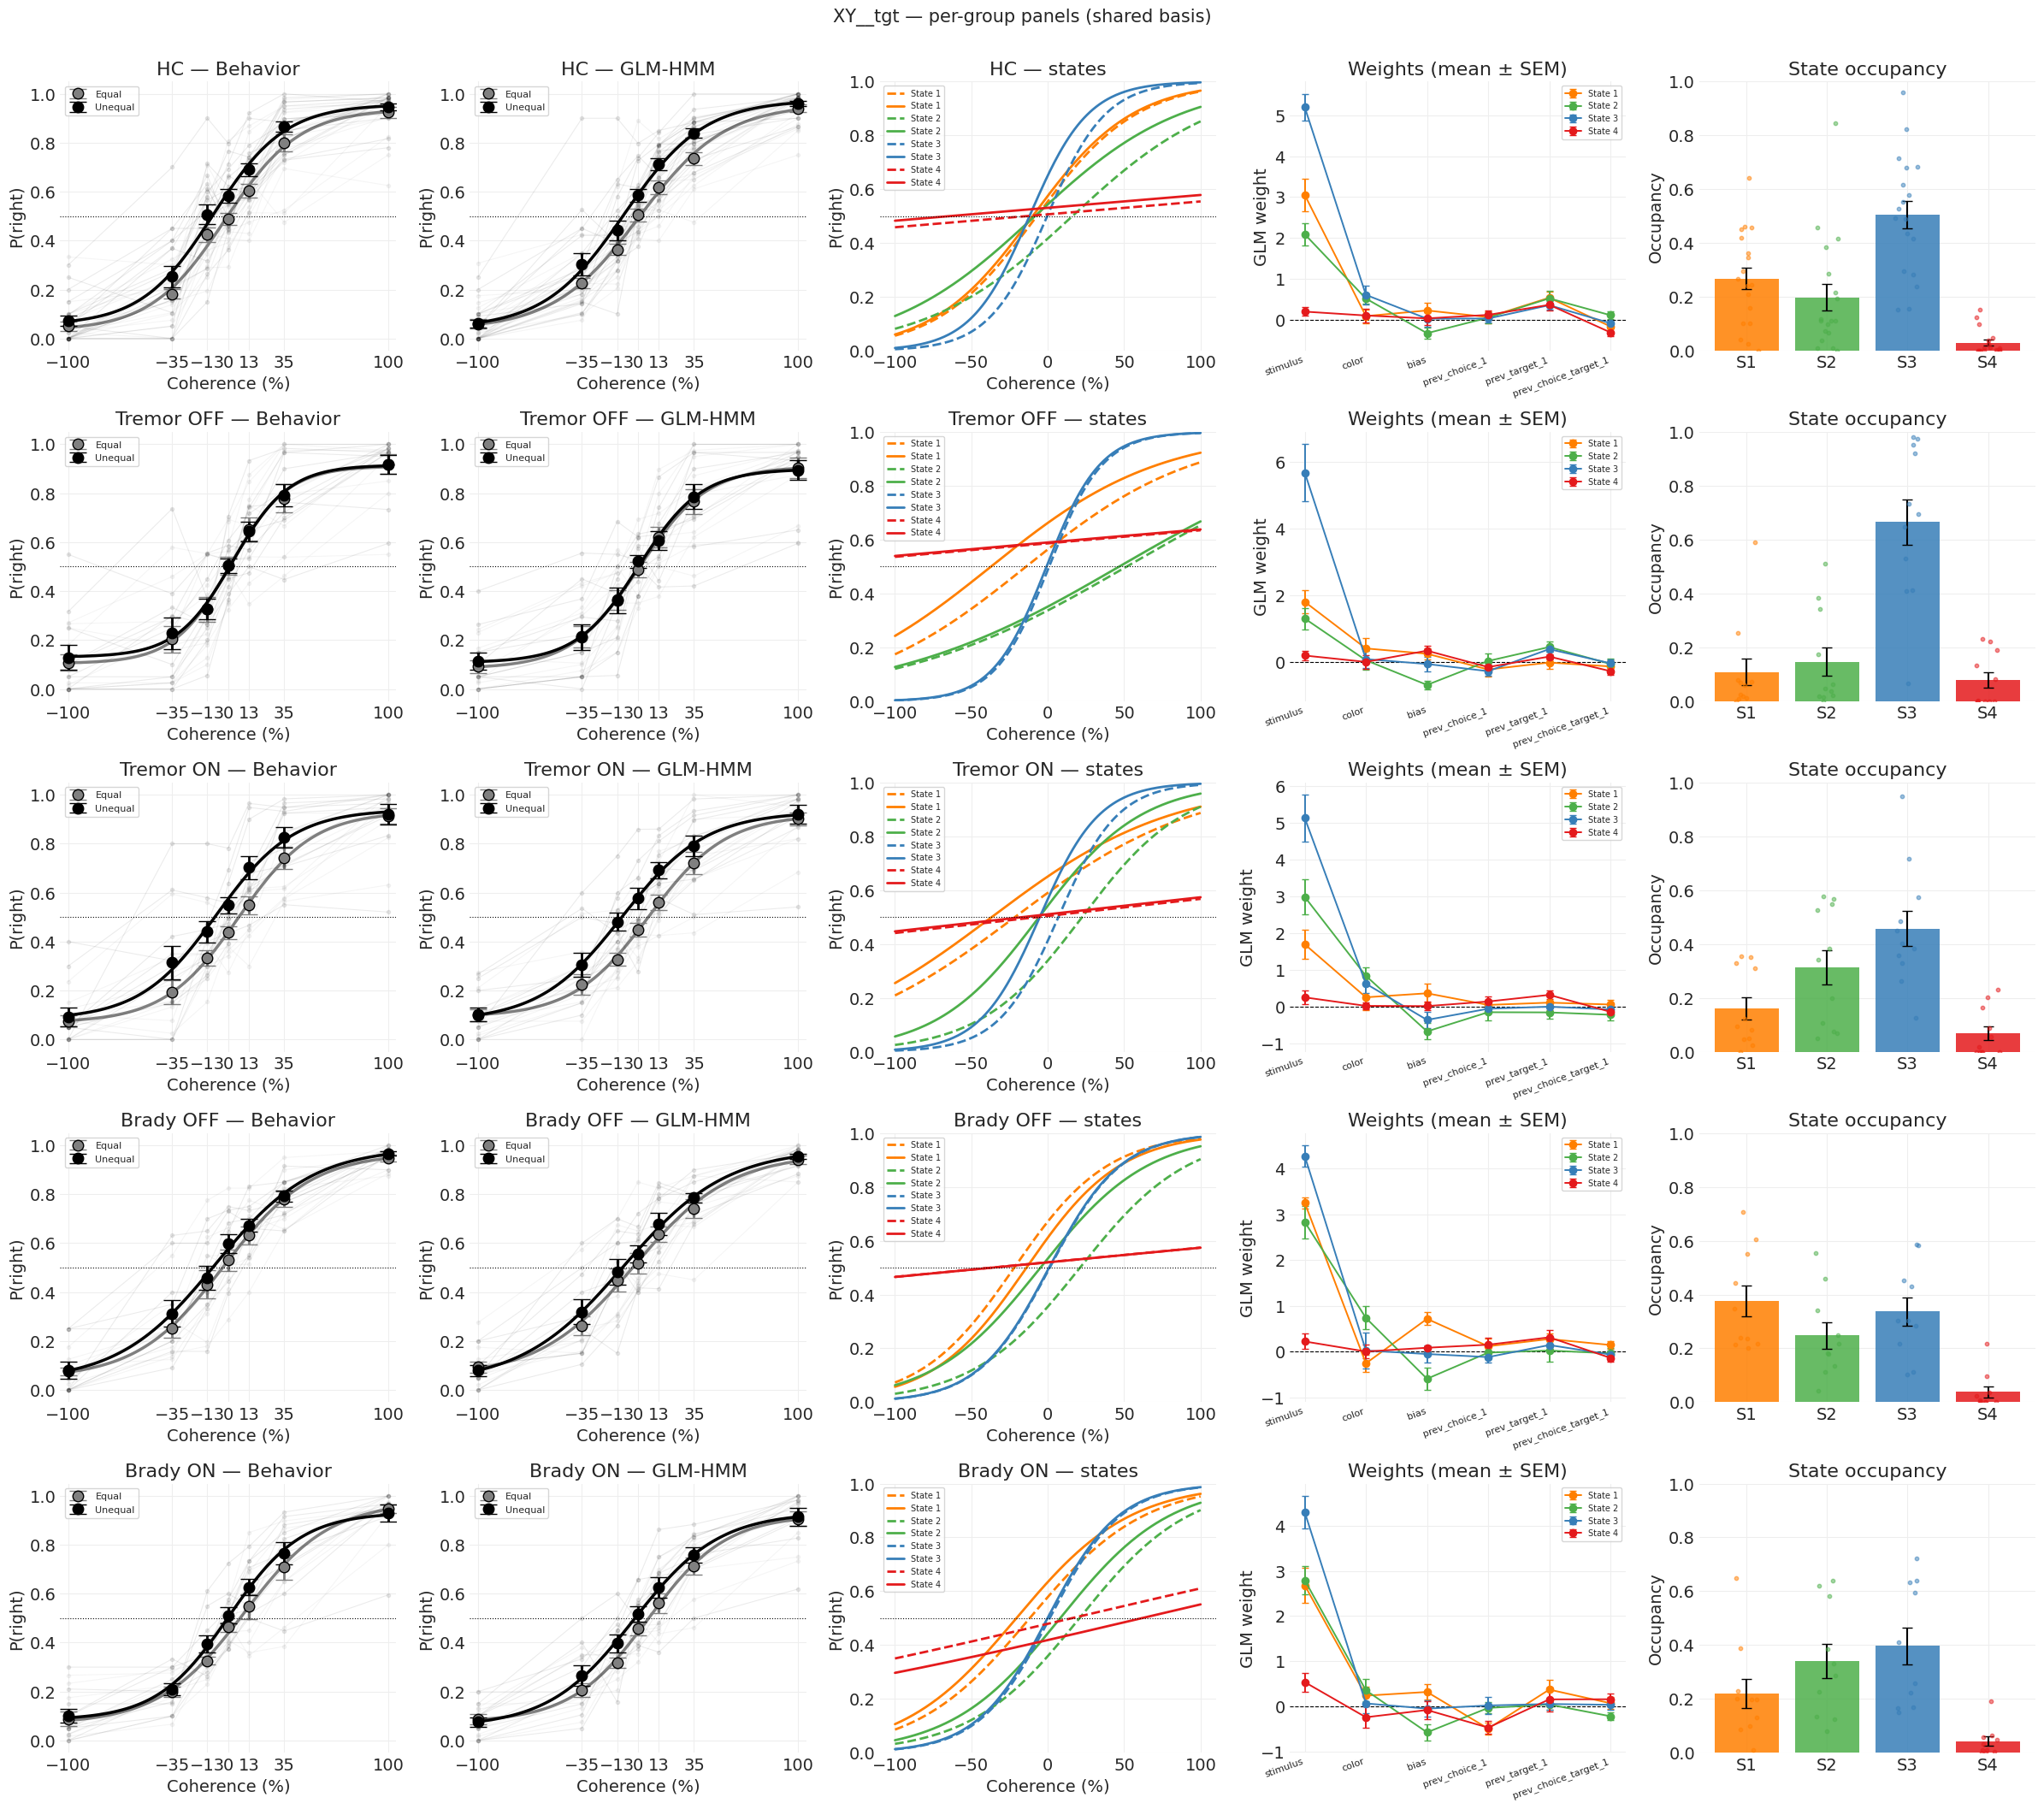

In [7]:

group_data = build_group_data(bundle, sess_md)
GROUP_ORDER = [("HC","none"), ("tremor","off"), ("tremor","on"),
               ("bradykinetic","off"), ("bradykinetic","on")]
GROUP_ORDER = [g for g in GROUP_ORDER if g in group_data]

nG = len(GROUP_ORDER)
fig, axes = plt.subplots(nG, 5, figsize=(24, 4.2*nG), squeeze=False)
for row, g in enumerate(GROUP_ORDER):
    plot_group_row(axes[row], g, group_data[g])
fig.suptitle(f"{SELECTED} \u2014 per-group panels (shared basis)", fontsize=15, y=1.005)
plt.tight_layout();
plt.show()

## 1. Per-state weights & the color-bias state

States are defined once by the shared pooled model. Identify the color-bias state as the
one with the largest `color` weight.

In [22]:
w = -pooled.observations.params[:, 0, :]   # (K, M)

wdf = pd.DataFrame(w, columns=feats, index=[f"S{k}" for k in range(K)])
wdf.round(3)

,stimulus,color,bias,prev_choice_1,prev_target_1,prev_choice_target_1
S0,3.000,0.038,0.629,0.114,0.379,-0.097
S1,2.956,0.334,-0.578,-0.043,0.189,0.025
S2,7.900,0.283,-0.107,-0.001,0.116,-0.086
S3,0.702,0.169,0.017,0.013,0.511,0.031


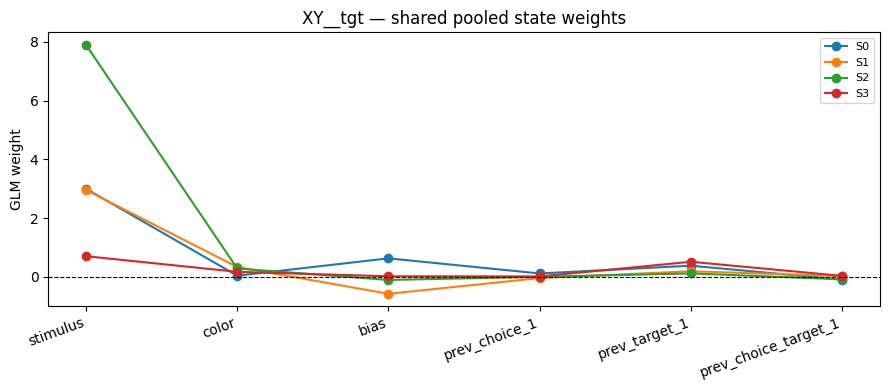

In [23]:
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(feats))
for k in range(K):
    lw = 1.5
    ax.plot(x, w[k], marker="o", lw=lw, label=f"S{k}")
ax.axhline(0, color="k", ls="--", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(feats, rotation=20, ha="right")
ax.set(ylabel="GLM weight", title=f"{CONFIG} — shared pooled state weights")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

In [24]:
# name states
state_names = {"S0": "Positive biased", "S1": "Negative biased", "S2": "Unbiased", "S3": "Lapse"}

## 2. Per-session occupancy under the shared pooled model

Occupancy = mean posterior state probability over a session's valid trials, computed with
the **single shared model** (identical basis for every session — no refit, no alignment).

In [25]:
def session_occupancy(model, df, feats):
    obs = df["choices"].values.astype(int).reshape(-1, 1)
    inp = df[feats].values.astype(float)
    msk = df["mask"].values.astype(bool).reshape(-1, 1)
    post = model.expected_states(data=obs, input=inp, mask=msk)[0]   # (T, K)
    return post[msk[:, 0]].mean(axis=0)

rows = []
for sid, df in data.items():
    occ = session_occupancy(pooled, df, feats)
    row = {"session_id": sid, **{state_names[f"S{k}"]: occ[k] for k in range(K)}}
    rows.append(row)
occ_df = pd.DataFrame(rows).set_index("session_id")
# if colorbias_state >= 0:
#     occ_df["occ_colorbias"] = occ_df[f"occ_S{colorbias_state}"]

occ_df = occ_df.join(sess_md)
occ_df["subtype"] = pd.Categorical(occ_df["subtype"], ["HC", "tremor", "bradykinetic", "intermediate"])
print("occupancy table:", occ_df.shape)
occ_cols = [state_names[f"S{k}"] for k in range(K)]
occ_df.groupby(["subtype", "medication"], observed=True)[occ_cols].agg(["mean", "sem", "count"]).round(3)

occupancy table: (100, 8)


Positive biased              Negative biased         \
                                   mean    sem count            mean    sem   
subtype      medication                                                       
HC           none                 0.308  0.039    18           0.313  0.060   
tremor       off                  0.185  0.080    11           0.242  0.083   
             on                   0.216  0.071    11           0.374  0.087   
bradykinetic off                  0.427  0.076    10           0.397  0.069   
             on                   0.233  0.044    10           0.499  0.071   
intermediate off                  0.242    NaN     1           0.081    NaN   
             on                   0.572    NaN     1           0.098    NaN   

                              Unbiased               Lapse               
                        count     mean    sem count   mean    sem count  
subtype      medication                                                  
HC           none          18    0.312  0.059    18  0.067  0.028    18  
tremor       off           11    0.392  0.124    11  0.181  0.095    11  
             on            11    0.288  0.091    11  0.122  0.059    11  
bradykinetic off           10    0.138  0.033    10  0.038  0.023    10  
             on            10    0.194  0.061    10  0.074  0.063    10  
intermediate off            1    0.677    NaN     1  0.000    NaN     1  
             on             1    0.330    NaN     1  0.000    NaN     1

## 3. Within-subject OFF→ON paired test (color-bias state)

Paired Wilcoxon on the 41 PD subjects, overall and per subtype.

In [26]:
pd_occ = occ_df[occ_df["is_pd"] == 1].copy()

def paired_test(state, sub):
    paired = (pd_occ.pivot_table(index=["subject_id", "subtype"], columns="medication",
                                 values=state, observed=True)
              .dropna(subset=["off", "on"]).reset_index())
    d = paired if sub is None else paired[paired["subtype"] == sub]
    if len(d) < 3:
        return dict(state=state, group=sub or "all_PD", n=len(d), off=np.nan, on=np.nan, delta=np.nan, p=np.nan)
    _, pval = wilcoxon(d["off"], d["on"])
    return dict(state=state, group=sub or "all_PD", n=len(d),
                off=d["off"].mean(), on=d["on"].mean(), delta=(d["on"] - d["off"]).mean(), p=pval)

res = pd.DataFrame([paired_test(state, sub)
                    for state in occ_cols
                    for sub in [None, "tremor", "bradykinetic"]])
print("Paired Wilcoxon: OFF vs ON occupancy, per state x group")
res.set_index(["state", "group"]).round(4)

Paired Wilcoxon: OFF vs ON occupancy, per state x group


n     off      on   delta       p
state           group                                           
Positive biased all_PD        22  0.2976  0.2396 -0.0580  0.5879
                tremor        11  0.1854  0.2158  0.0304  0.7646
                bradykinetic  10  0.4267  0.2326 -0.1940  0.1934
Negative biased all_PD        22  0.3052  0.4184  0.1132  0.0542
                tremor        11  0.2423  0.3743  0.1320  0.0674
                bradykinetic  10  0.3968  0.4988  0.1020  0.3223
Unbiased        all_PD        22  0.2893  0.2475 -0.0418  0.8736
                tremor        11  0.3915  0.2883 -0.1032  0.8311
                bradykinetic  10  0.1380  0.1943  0.0563  0.3223
Lapse           all_PD        22  0.1079  0.0945 -0.0133  0.9240
                tremor        11  0.1807  0.1216 -0.0592  0.9658
                bradykinetic  10  0.0385  0.0742  0.0357  1.0000

## 4. Subtype × medication mixed model

`occ_colorbias ~ medication * subtype` with a per-subject random intercept (tremor vs
brady only; the interaction term tests whether medication's effect differs by subtype).

In [27]:
# Mixed model per state: occupancy ~ C(medication)*C(subtype) + (1|subject)
# references: medication=off, subtype=bradykinetic  -> "med" = ON-OFF in brady;
# "med"+"inter" = ON-OFF in tremor; "inter_p" = does the medication effect differ by subtype.
mm_base = pd_occ[pd_occ["subtype"].isin(["tremor", "bradykinetic"])].copy()
mm_base["medication"] = pd.Categorical(mm_base["medication"], ["off", "on"])
mm_base["subtype"] = mm_base["subtype"].astype(str)

def fit_state(state):
    mm = mm_base.copy()
    mm["y"] = mm[state]
    med, sub, inter = "C(medication)[T.on]", "C(subtype)[T.tremor]", "C(medication)[T.on]:C(subtype)[T.tremor]"
    try:
        f = smf.mixedlm("y ~ C(medication) * C(subtype)", mm, groups=mm["subject_id"]).fit(reml=False)
        return dict(state=state,
                    med_coef=f.params.get(med, np.nan), med_p=f.pvalues.get(med, np.nan),
                    subtype_coef=f.params.get(sub, np.nan), subtype_p=f.pvalues.get(sub, np.nan),
                    inter_coef=f.params.get(inter, np.nan), inter_p=f.pvalues.get(inter, np.nan))
    except Exception as e:
        print(f"  {state}: mixed model failed: {e}")
        return dict(state=state)

mm_res = pd.DataFrame([fit_state(s) for s in occ_cols]).set_index("state")
print("Mixed model per state (ON-OFF medication, subtype, and their interaction):")
mm_res.round(4)

Mixed model per state (ON-OFF medication, subtype, and their interaction):


,med_coef,med_p,subtype_coef,subtype_p,inter_coef,inter_p
state,,,,,,
Positive biased,-0.1940,0.0359,-0.2413,0.0106,0.2244,0.0791
Negative biased,0.1020,0.1775,-0.1545,0.1460,0.0300,0.7742
Unbiased,0.0563,0.5246,0.2535,0.0306,-0.1595,0.1919
Lapse,0.0357,0.6495,0.1422,0.1133,-0.0949,0.3822


## 5. Within-subject occupancy plot

Per-subject OFF→ON slope lines by subtype, group means ± SEM, and the HC reference band.

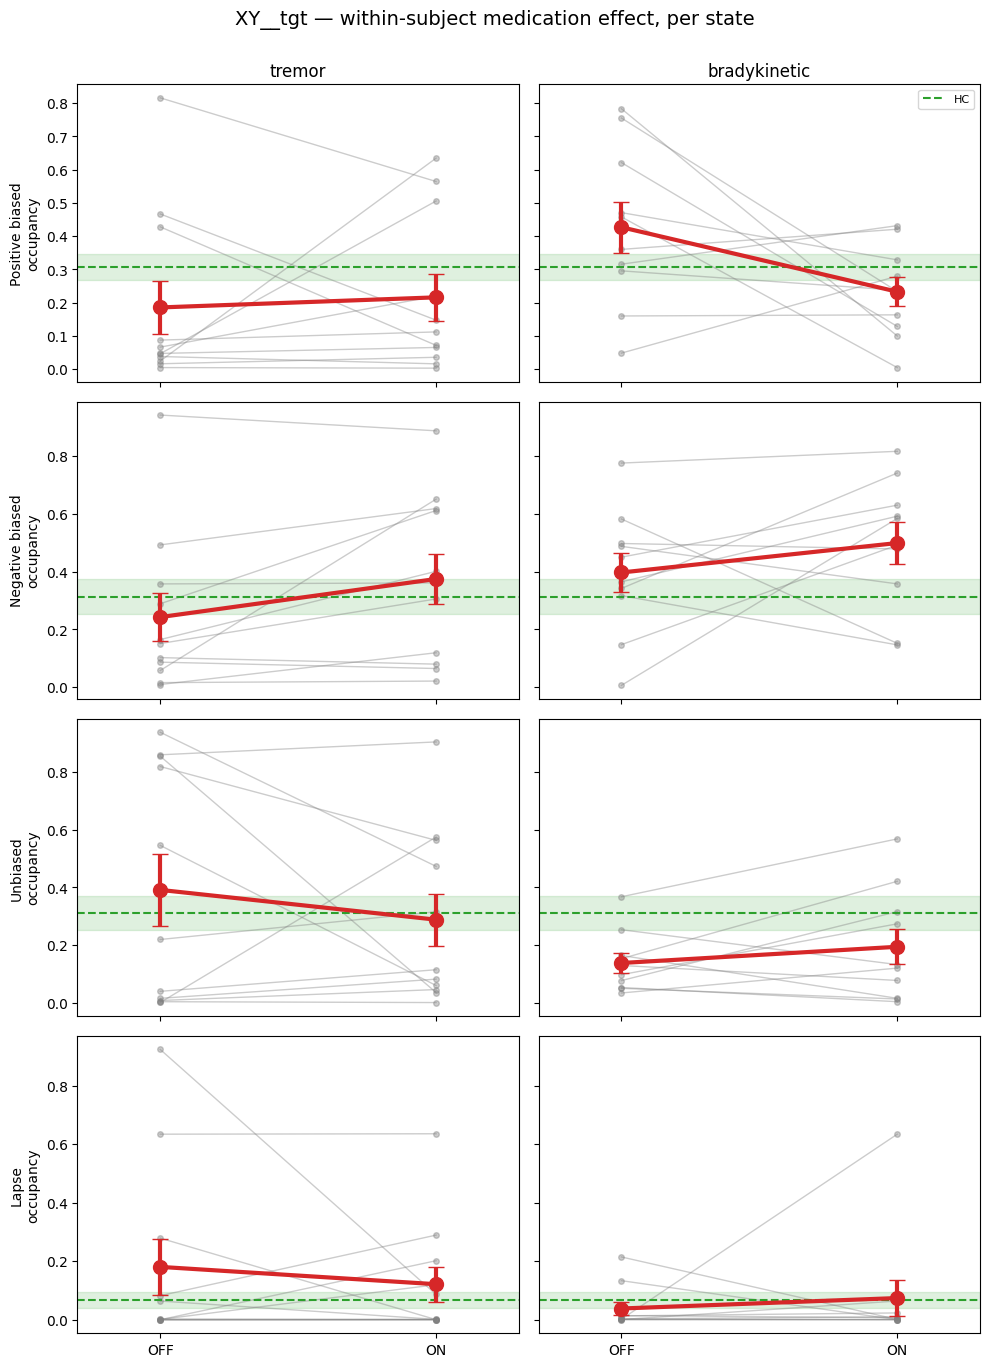

In [28]:
def state_paired(state):
    return (pd_occ.pivot_table(index=["subject_id", "subtype"], columns="medication",
                               values=state, observed=True)
            .dropna(subset=["off", "on"]).reset_index())

subtypes = ["tremor", "bradykinetic"]
fig, axes = plt.subplots(len(occ_cols), len(subtypes),
                         figsize=(5 * len(subtypes), 3.4 * len(occ_cols)),
                         squeeze=False, sharex=True, sharey="row")
for si, state in enumerate(occ_cols):
    hc = occ_df[occ_df["subtype"] == "HC"][state]
    hc_mean, hc_sem = hc.mean(), hc.sem()
    pr = state_paired(state)
    for ai, sub in enumerate(subtypes):
        ax = axes[si][ai]
        d = pr[pr["subtype"] == sub]
        for _, r in d.iterrows():
            ax.plot([0, 1], [r["off"], r["on"]], "-o", color="gray", alpha=0.4, lw=1, ms=4)
        ax.errorbar([0, 1], [d["off"].mean(), d["on"].mean()], yerr=[d["off"].sem(), d["on"].sem()],
                    color="tab:red", lw=3, marker="o", ms=10, capsize=6, zorder=5)
        ax.axhspan(hc_mean - hc_sem, hc_mean + hc_sem, color="tab:green", alpha=0.15)
        ax.axhline(hc_mean, color="tab:green", ls="--", lw=1.5, label="HC")
        ax.set_xticks([0, 1]); ax.set_xticklabels(["OFF", "ON"]); ax.set_xlim(-0.3, 1.3)
        if si == 0:
            ax.set_title(f"{sub}", fontsize=12)
        if ai == 0:
            ax.set_ylabel(f"{state}\noccupancy", fontsize=10)
        if si == 0 and ai == len(subtypes) - 1:
            ax.legend(fontsize=8)
fig.suptitle(f"{CONFIG} \u2014 within-subject medication effect, per state", fontsize=14, y=1.002)
plt.tight_layout(); plt.show()

## 6. All-state occupancy by subtype × medication

Full state-occupancy profile, to see which states (not just color-bias) shift with
medication / differ across subtypes.

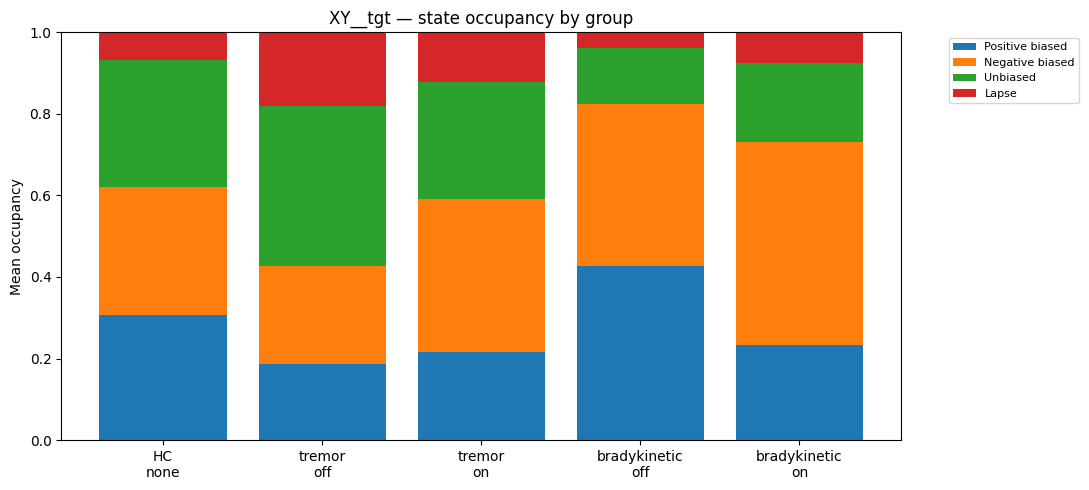

In [29]:
occ_cols = [state_names[f"S{k}"] for k in range(K)]
summary = occ_df.groupby(["subtype", "medication"], observed=True)[occ_cols].mean()

groups = [("HC", "none"), ("tremor", "off"), ("tremor", "on"),
          ("bradykinetic", "off"), ("bradykinetic", "on")]
groups = [g for g in groups if g in summary.index]
labels = [f"{s}\n{m}" for s, m in groups]

fig, ax = plt.subplots(figsize=(11, 5))
bottom = np.zeros(len(groups))
for k in range(K):
    vals = np.array([summary.loc[g, state_names[f"S{k}"]] for g in groups])
    lbl = state_names[f"S{k}"]
    ax.bar(labels, vals, bottom=bottom, label=lbl)
    bottom += vals
ax.set(ylabel="Mean occupancy", title=f"{CONFIG} — state occupancy by group", ylim=(0, 1))
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8);
plt.tight_layout();
plt.show()